# Pro Match Draft Transformer — Draft-based Win Prediction

Predicts the outcome of professional LoL matches using only the draft (picks + bans).

**Data:** `src/data/oracleselixir/` — Oracle's Elixir yearly CSVs (2020–2026)

**Architecture: DraftTransformer**
- 10 pick tokens (blue 0–4, red 5–9), each with: champion + team + side + role + pick-order embeddings
- 4-layer Transformer encoder with pre-LayerNorm and GELU activation
- Full self-attention: every pick attends to every other pick — synergies and counters in one pass
- Ban context (mean of 10 ban embeddings) + patch embedding appended to classifier
- Mixed-precision training (bfloat16) for 4070 Ti

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt

from data.oracleselixir import load_raw, build_game_df, build_vocabularies
from models.draft_transformer import DraftTransformer, DraftDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Device: {device}  |  Mixed precision: {use_amp}")

Device: cuda  |  Mixed precision: True


## 1. Load & Preprocess Data

In [2]:
DATA_PATH = "../src/data/oracleselixir"   # yearly CSVs from Oracle's Elixir

raw = load_raw(DATA_PATH, complete_only=True)
print(f"Complete rows: {len(raw):,}  |  columns: {len(raw.columns)}")
print(raw[["gameid", "league", "year", "patch", "side", "position",
           "teamname", "champion", "firstPick", "result"]].head(12))

Complete rows: 747,984  |  columns: 165
                   gameid league  year  patch  side position      teamname  \
0   ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue      top  Liiv SANDBOX   
1   ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue      jng  Liiv SANDBOX   
2   ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue      mid  Liiv SANDBOX   
3   ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue      bot  Liiv SANDBOX   
4   ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue      sup  Liiv SANDBOX   
5   ESPORTSTMNT03/1241318  KeSPA  2020   9.24   Red      top            T1   
6   ESPORTSTMNT03/1241318  KeSPA  2020   9.24   Red      jng            T1   
7   ESPORTSTMNT03/1241318  KeSPA  2020   9.24   Red      mid            T1   
8   ESPORTSTMNT03/1241318  KeSPA  2020   9.24   Red      bot            T1   
9   ESPORTSTMNT03/1241318  KeSPA  2020   9.24   Red      sup            T1   
10  ESPORTSTMNT03/1241318  KeSPA  2020   9.24  Blue     team  Liiv SANDBOX   
11  ESPORTSTMNT03/124131

In [3]:
game_df = build_game_df(raw)
print(f"Games (wide format): {len(game_df):,}")
print(f"Leagues: {sorted(game_df['league'].unique())}")
print(f"Date range: {game_df['date'].min().date()} → {game_df['date'].max().date()}")
print(f"Blue win rate: {game_df['blue_win'].mean():.1%}")
game_df.head(3)

Games (wide format): 62,332
Leagues: ['AC', 'AL', 'AOL', 'ASI', 'Asia Master', 'BIG', 'BL', 'BM', 'BRCC', 'CBLOL', 'CBLOLA', 'CCWS', 'CD', 'CDF', 'CK', 'CT', 'CU', 'DCup', 'DDH', 'DL', 'EBL', 'EBLPA', 'EGL', 'EL', 'EM', 'EPL', 'ESLOL', 'EUM', 'EWC', 'FST', 'GL', 'GLL', 'GLLPA', 'GSG', 'HC', 'HLL', 'HM', 'HS', 'HW', 'IC', 'IGNIS', 'KeSPA', 'LAS', 'LCK', 'LCKC', 'LCL', 'LCO', 'LCP', 'LCS', 'LCSA', 'LDL', 'LEC', 'LES', 'LFL', 'LFL2', 'LHE', 'LIT', 'LJL', 'LJLA', 'LLA', 'LMF', 'LPL', 'LPLOL', 'LRN', 'LRS', 'LTA', 'LTA N', 'LTA S', 'LVP SL', 'MSC', 'MSI', 'NACL', 'NASG', 'NERD', 'NEST', 'NEXO', 'NL', 'NLC', 'NLC Aurora Open', 'OCS', 'OPL', 'OTBLX', 'PCL', 'PCS', 'PGC', 'PGN', 'PRM', 'PRMP', 'RCL', 'RL', 'ROL', 'Riot', 'SL (LATAM)', 'SLO', 'TAL', 'TCL', 'TSC', 'UGP', 'UKLC', 'UL', 'UPL', 'USP', 'VCS', 'VL', 'WLDs']
Date range: 2020-01-03 → 2026-04-30
Blue win rate: 52.8%


,gameid,patch,league,date,blue_first_pick,blue_top,red_top,blue_pick_order_top,red_pick_order_top,blue_jng,...,red_ban2,blue_ban3,red_ban3,blue_ban4,red_ban4,blue_ban5,red_ban5,blue_team,red_team,blue_win
0,ESPORTSTMNT03/1241318,9.24,KeSPA,2020-01-03 07:33:26,1,Rumble,Aatrox,1,3,Elise,...,Akali,Rek'Sai,Lee Sin,Yasuo,Olaf,Renekton,Jarvan IV,Liiv SANDBOX,T1,1
1,ESPORTSTMNT03/1241322,9.24,KeSPA,2020-01-03 09:00:58,1,Jayce,Aatrox,4,2,Jarvan IV,...,Akali,Rumble,Rek'Sai,Braum,Irelia,Leona,Camille,T1,Liiv SANDBOX,0
2,ESPORTSTMNT03/1241324,9.24,KeSPA,2020-01-03 10:05:17,1,Renekton,Aatrox,4,2,Rek'Sai,...,Akali,Lee Sin,Elise,Gragas,Irelia,Olaf,Orianna,T1,Liiv SANDBOX,1


## 2. Vocabularies & Dataset

In [4]:
champ2idx, team2idx, patch2idx = build_vocabularies(game_df)
print(f"Champions: {len(champ2idx)}  |  Teams: {len(team2idx)}  |  Patches: {len(patch2idx)}")

# Check pick order coverage
pick_order_cols = [f"blue_pick_order_{r}" for r in ["top","jng","mid","bot","sup"]]
coverage = (game_df[pick_order_cols] >= 0).all(axis=1).mean()
print(f"Pick order known: {coverage:.1%} of games")
game_df[["blue_team", "red_team", "blue_top", "red_top",
         "blue_pick_order_top", "red_pick_order_top",
         "blue_ban1", "red_ban1", "blue_win"]].head(3)

Champions: 172  |  Teams: 1789  |  Patches: 147
Pick order known: 87.1% of games


,blue_team,red_team,blue_top,red_top,blue_pick_order_top,red_pick_order_top,blue_ban1,red_ban1,blue_win
0,Liiv SANDBOX,T1,Rumble,Aatrox,1,3,LeBlanc,Lucian,1
1,T1,Liiv SANDBOX,Jayce,Aatrox,4,2,Syndra,Lucian,0
2,T1,Liiv SANDBOX,Renekton,Aatrox,4,2,LeBlanc,Lucian,1


## 3. Train / Validation / Test Split

Split chronologically — never shuffle before splitting, otherwise future matches leak into training.

In [5]:
n       = len(game_df)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

train_df = game_df.iloc[:n_train].reset_index(drop=True)
val_df   = game_df.iloc[n_train:n_val].reset_index(drop=True)
test_df  = game_df.iloc[n_val:].reset_index(drop=True)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Test period: {test_df['date'].min().date()} → {test_df['date'].max().date()}")

def make_loader(df, shuffle=False, batch_size=256):
    ds = DraftDataset(df, champ2idx, team2idx, patch2idx)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=4, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df)
test_loader  = make_loader(test_df)

Train: 43,632  |  Val: 9,350  |  Test: 9,350
Test period: 2025-04-27 → 2026-04-30


## 4. Train

In [6]:
model = DraftTransformer(
    num_champions = len(champ2idx),
    num_teams     = len(team2idx),
    num_patches   = len(patch2idx),
    champ_dim  = 64,
    team_dim   = 16,
    d_model    = 256,
    nhead      = 8,
    num_layers = 4,
    dropout    = 0.1,
).to(device)

# torch.compile gives ~20-30% speedup on a 4070 Ti for Transformer models
model = torch.compile(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)
scaler    = GradScaler(enabled=use_amp)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 3,386,337


In [7]:
KEYS = ["champ_ids", "team_ids", "side_ids", "role_ids", "pick_pos", "ban_ids", "patch_idx"]

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss, y_true, y_proba = 0.0, [], []

    for batch in loader:
        inputs = {k: batch[k].to(device) for k in KEYS}
        labels = batch["label"].to(device)

        with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_amp):
            logits = model(**inputs)
            loss   = F.binary_cross_entropy_with_logits(logits, labels)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * len(labels)
        y_true.extend(labels.cpu().tolist())
        y_proba.extend(torch.sigmoid(logits).detach().float().cpu().tolist())

    n = len(y_true)
    y_pred = [p > 0.5 for p in y_proba]
    return {
        "loss": total_loss / n,
        "acc":  accuracy_score(y_true, y_pred),
        "auc":  roc_auc_score(y_true, y_proba),
    }


PATIENCE = 15
best_val_loss = float("inf")
best_epoch    = 0
best_state    = None

EPOCHS  = 60
history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader)
    scheduler.step()
    history["train"].append(tr)
    history["val"].append(vl)

    if vl["loss"] < best_val_loss:
        best_val_loss = vl["loss"]
        best_epoch    = epoch
        raw_model     = model._orig_mod if hasattr(model, "_orig_mod") else model
        best_state    = {k: v.cpu().clone() for k, v in raw_model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"train loss {tr['loss']:.4f}  acc {tr['acc']:.3f}  auc {tr['auc']:.3f} | "
              f"val   loss {vl['loss']:.4f}  acc {vl['acc']:.3f}  auc {vl['auc']:.3f}")

    if epoch - best_epoch >= PATIENCE:
        print(f"Early stopping at epoch {epoch}  (best val loss at epoch {best_epoch})")
        break

# Restore best checkpoint
raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
raw_model.load_state_dict(best_state)
print(f"\nRestored best checkpoint from epoch {best_epoch}  (val loss {best_val_loss:.4f})")

Epoch   1 | train loss 0.7011  acc 0.513  auc 0.499 | val   loss 0.6928  acc 0.509  auc 0.498
Epoch   5 | train loss 0.6880  acc 0.543  auc 0.552 | val   loss 0.6875  acc 0.546  auc 0.550
Epoch  10 | train loss 0.6386  acc 0.639  auc 0.684 | val   loss 0.7169  acc 0.527  auc 0.530
Epoch  15 | train loss 0.5542  acc 0.717  auc 0.788 | val   loss 0.8296  acc 0.520  auc 0.526
Epoch  20 | train loss 0.4911  acc 0.765  auc 0.841 | val   loss 0.9109  acc 0.521  auc 0.526
Early stopping at epoch 20  (best val loss at epoch 5)

Restored best checkpoint from epoch 5  (val loss 0.6875)


## 5. Evaluate on Test Set

Test accuracy: 0.532
Test ROC AUC:  0.539
Model saved to ../models/draft_transformer.pt


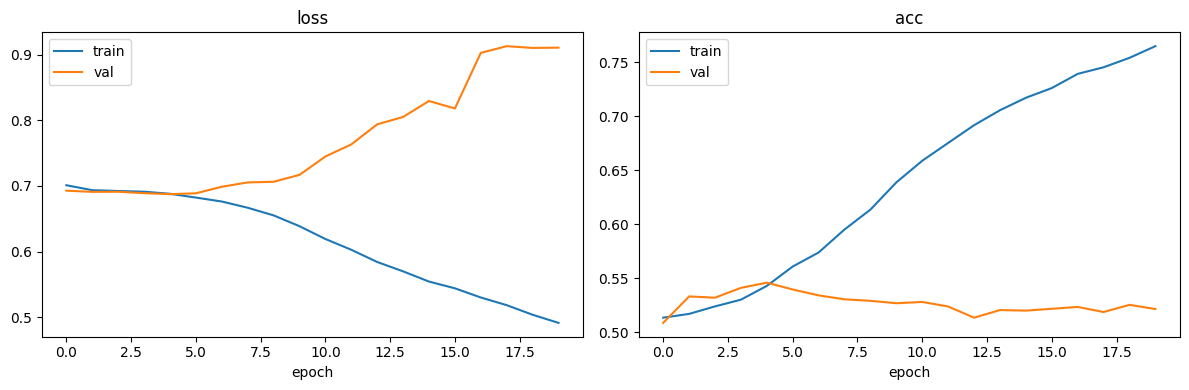

In [8]:
test_res = run_epoch(test_loader)
print(f"Test accuracy: {test_res['acc']:.3f}")
print(f"Test ROC AUC:  {test_res['auc']:.3f}")

# Save best-checkpoint weights
import os
os.makedirs("../models", exist_ok=True)
torch.save(best_state, "../models/draft_transformer.pt")
print("Model saved to ../models/draft_transformer.pt")

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["loss", "acc"]):
    ax.plot([e[metric] for e in history["train"]], label="train")
    ax.plot([e[metric] for e in history["val"]],   label="val")
    ax.set_title(metric)
    ax.legend()
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 6. Per-League Breakdown

In [9]:
model.eval()
all_proba = []
with torch.no_grad():
    for batch in test_loader:
        inputs = {k: batch[k].to(device) for k in KEYS}
        with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_amp):
            logits = model(**inputs)
        all_proba.extend(torch.sigmoid(logits).float().cpu().tolist())

test_df = test_df.copy()
test_df["proba"]         = all_proba
test_df["pred_blue_win"] = [p > 0.5 for p in all_proba]

league_stats = (
    test_df
    .groupby("league")
    .apply(lambda g: pd.Series({
        "games":    len(g),
        "accuracy": (g["pred_blue_win"] == g["blue_win"]).mean(),
        "auc":      roc_auc_score(g["blue_win"], g["proba"]) if g["blue_win"].nunique() > 1 else float("nan"),
    }))
    .query("games >= 20")
    .sort_values("auc", ascending=False)
)
print(league_stats.to_string())

             games  accuracy       auc
league                                
DCup          75.0  0.546667  0.692641
KeSPA         56.0  0.517857  0.667097
LPLOL        152.0  0.559211  0.655627
NL            24.0  0.625000  0.647059
CCWS          40.0  0.475000  0.631510
LTA N        153.0  0.529412  0.615925
HW           103.0  0.611650  0.602519
LRN          164.0  0.548780  0.597278
PRMP          35.0  0.657143  0.593333
LCK          568.0  0.524648  0.592933
FST           45.0  0.622222  0.586667
LTA           22.0  0.545455  0.581197
LTA S        155.0  0.509677  0.570498
RL           204.0  0.490196  0.570328
HC           197.0  0.548223  0.569610
LES           61.0  0.606557  0.567100
LRS          177.0  0.559322  0.566044
NEXO          77.0  0.493506  0.564626
AL           370.0  0.551351  0.563706
LVP SL       135.0  0.607407  0.557064
ROL          236.0  0.512712  0.554904
NLC          188.0  0.521277  0.549762
LIT          198.0  0.515152  0.548331
NACL         279.0  0.544

## 7. Calibration — Temperature Scaling

Raw model probabilities are overconfident. Temperature scaling fits one scalar `T` on the **validation set** so the output probabilities are reliable for betting.

Temperature fitted: T = 1.0660  (less confident than raw output)
Log-loss  before calibration: 0.6901
Log-loss  after  calibration: 0.6899
ECE after calibration:        0.0163


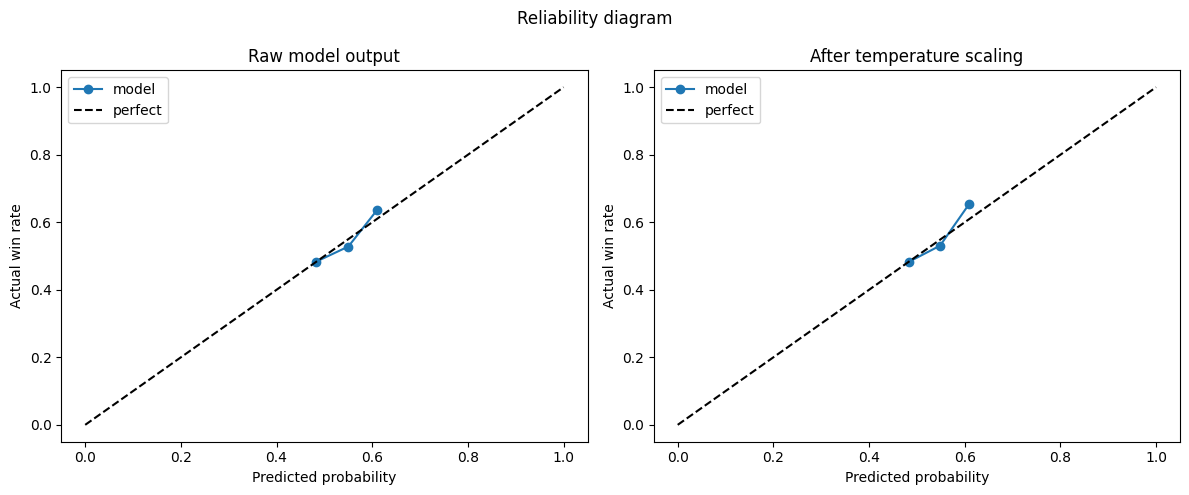

In [10]:
import numpy as np
from sklearn.calibration import calibration_curve
from models.uncertainty import TemperatureScaler

def collect_probs(loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = {k: batch[k].to(device) for k in KEYS}
            with autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_amp):
                logits = model(**inputs)
            probs.extend(torch.sigmoid(logits).float().cpu().tolist())
            labels.extend(batch["label"].tolist())
    return np.array(probs), np.array(labels)

val_probs,  val_labels  = collect_probs(val_loader)
test_probs, test_labels = collect_probs(test_loader)

scaler = TemperatureScaler()
scaler.fit(val_probs, val_labels)
cal_probs = scaler.calibrate(test_probs)

print(f"Log-loss  before calibration: {log_loss(test_labels, test_probs):.4f}")
print(f"Log-loss  after  calibration: {log_loss(test_labels, cal_probs):.4f}")
print(f"ECE after calibration:        {scaler.calibration_error(test_probs, test_labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, probs, title in zip(axes,
                             [test_probs, cal_probs],
                             ["Raw model output", "After temperature scaling"]):
    frac_pos, mean_pred = calibration_curve(test_labels, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label="model")
    ax.plot([0, 1], [0, 1], "k--", label="perfect")
    ax.set_title(title)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Actual win rate")
    ax.legend()
plt.suptitle("Reliability diagram")
plt.tight_layout()
plt.show()

## 8. Uncertainty — MC Dropout

100 stochastic forward passes with dropout active → mean prediction + 95% interval.  
Wide interval = model hasn't seen similar matchups = skip the bet.

Median uncertainty (std): 0.0171
Confident predictions (std ≤ 0.05): 100.0%
Confident predictions (std ≤ 0.08): 100.0%


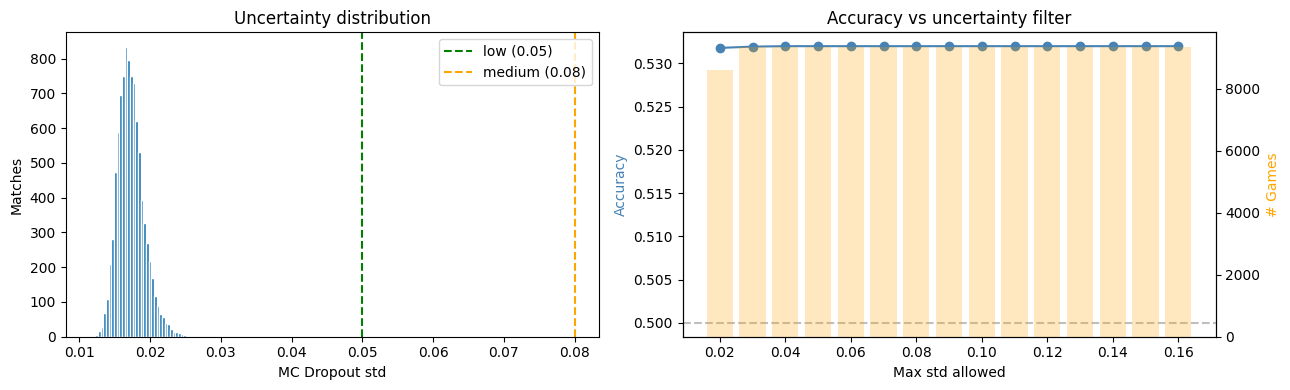

In [11]:
from models.uncertainty import MCDropoutPredictor

# Use uncompiled model for MC Dropout (compile adds wrapper that respects train mode fine,
# but uncompiled is simpler to reason about)
raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
mc = MCDropoutPredictor(raw_model, scaler=scaler, n_samples=100, use_amp=use_amp)

all_mean, all_std, all_lower, all_upper = [], [], [], []
for batch in test_loader:
    inputs = {k: batch[k] for k in KEYS}
    res = mc.predict(inputs, device)
    all_mean.extend(res["mean"].tolist())
    all_std.extend(res["std"].tolist())
    all_lower.extend(res["lower95"].tolist())
    all_upper.extend(res["upper95"].tolist())

all_mean  = np.array(all_mean)
all_std   = np.array(all_std)
all_lower = np.array(all_lower)
all_upper = np.array(all_upper)

print(f"Median uncertainty (std): {np.median(all_std):.4f}")
print(f"Confident predictions (std ≤ 0.05): {(all_std <= 0.05).mean():.1%}")
print(f"Confident predictions (std ≤ 0.08): {(all_std <= 0.08).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: uncertainty distribution
axes[0].hist(all_std, bins=50, edgecolor="white")
axes[0].axvline(0.05, color="green",  linestyle="--", label="low (0.05)")
axes[0].axvline(0.08, color="orange", linestyle="--", label="medium (0.08)")
axes[0].set_xlabel("MC Dropout std")
axes[0].set_ylabel("Matches")
axes[0].set_title("Uncertainty distribution")
axes[0].legend()

# Right: accuracy as function of uncertainty threshold
thresholds = np.arange(0.02, 0.16, 0.01)
rows = []
for t in thresholds:
    mask = all_std <= t
    if mask.sum() >= 30:
        acc = ((all_mean[mask] > 0.5) == test_labels[mask]).mean()
        rows.append({"thresh": t, "acc": acc, "n": mask.sum()})
tdf = pd.DataFrame(rows)

ax2 = axes[1].twinx()
axes[1].plot(tdf["thresh"], tdf["acc"], marker="o", color="steelblue")
ax2.bar(tdf["thresh"], tdf["n"], width=0.008, alpha=0.25, color="orange")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Max std allowed")
axes[1].set_ylabel("Accuracy", color="steelblue")
ax2.set_ylabel("# Games", color="orange")
axes[1].set_title("Accuracy vs uncertainty filter")

plt.tight_layout()
plt.show()

## 9. Full Test-Set Results with Uncertainty

In [12]:
results_df = test_df[["date", "league", "blue_team", "red_team", "blue_win"]].copy()
results_df["cal_prob"]    = all_mean
results_df["uncertainty"] = all_std
results_df["interval_lo"] = all_lower
results_df["interval_hi"] = all_upper
results_df["correct"]     = (all_mean > 0.5) == test_labels
results_df["interval_width"] = all_upper - all_lower

# Summary per confidence tier
results_df["tier"] = pd.cut(
    results_df["uncertainty"],
    bins=[0, 0.04, 0.07, 0.10, 1.0],
    labels=["very confident (≤0.04)", "confident (≤0.07)", "moderate (≤0.10)", "uncertain (>0.10)"]
)
tier_summary = (
    results_df.groupby("tier", observed=True)
    .agg(games=("correct", "count"), accuracy=("correct", "mean"),
         avg_std=("uncertainty", "mean"), avg_interval=("interval_width", "mean"))
    .round(4)
)
print(tier_summary.to_string())

# Sort by confidence for display
results_df.sort_values("uncertainty").head(20)

                        games  accuracy  avg_std  avg_interval
tier                                                          
very confident (≤0.04)   9350     0.532   0.0172        0.0653


,date,league,blue_team,red_team,blue_win,cal_prob,uncertainty,interval_lo,interval_hi,correct,interval_width,tier
5787,2025-12-25 11:20:11,DCup,Bilibili Gaming,Weibo Gaming,1,0.578066,0.011477,0.558668,0.599118,True,0.040450,very confident (≤0.04)
3777,2025-08-17 17:48:56,LTA S,RED Canids,paiN Gaming,0,0.574317,0.012087,0.549401,0.593686,False,0.044285,very confident (≤0.04)
3727,2025-08-16 11:12:37,HM,eSuba,Entropiq,0,0.589691,0.012341,0.558668,0.606490,False,0.047822,very confident (≤0.04)
9081,2026-04-25 12:17:25,NL,Galions Sharks,Project Conquerors,1,0.563332,0.012398,0.540321,0.584392,True,0.044071,very confident (≤0.04)
3571,2025-08-13 05:09:08,LCKC,KT Rolster Challengers,T1 Esports Academy,1,0.573214,0.012399,0.551327,0.595435,True,0.044108,very confident (≤0.04)
1180,2025-05-20 20:15:13,LRN,PÊEK Gaming,Fuego,1,0.563148,0.012471,0.538396,0.584392,True,0.045997,very confident (≤0.04)
2368,2025-07-13 19:03:03,PRMP,Berlin International Gaming,TeamOrangeGaming Academy,1,0.547511,0.012476,0.523730,0.571616,True,0.047886,very confident (≤0.04)
359,2025-05-05 21:11:22,CD,Stellae Gaming,KaBuM! Ilha das Lendas,0,0.551400,0.012531,0.525654,0.573361,False,0.047707,very confident (≤0.04)
6576,2026-02-06 09:56:39,LCP,Ground Zero Gaming,CTBC Flying Oyster,1,0.600703,0.012653,0.577037,0.621254,True,0.044217,very confident (≤0.04)
5458,2025-10-17 08:09:42,WLDs,KT Rolster,Top Esports,1,0.527084,0.012699,0.503664,0.551327,True,0.047663,very confident (≤0.04)


## 10. Live Match Prediction

Fill in a real draft after champion select and get a calibrated win probability + 95% uncertainty interval.

────────────────────────────────────────────────────
  T1                   (Blue)  vs  Gen.G (Red)
  Patch 15.10
────────────────────────────────────────────────────
  Blue win probability : 54.2%
  95% interval         : [50.5%,  58.1%]  (width 7.5%)
  Uncertainty (std)    : 0.0177  ✓ confident

  Bookmaker odds (blue): 1.85
  Implied prob          : 54.0%
  Edge                  : +0.2%
  Kelly stake           : 0.1% of bankroll
  → SKIP — no edge
────────────────────────────────────────────────────


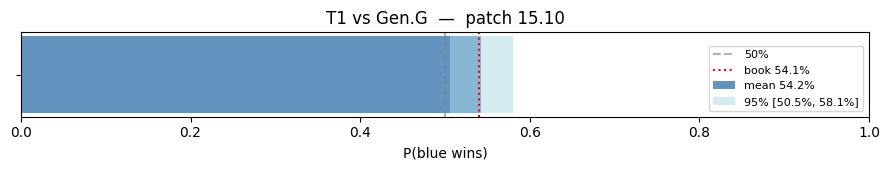

In [13]:
from models.draft_transformer import _row_to_tensors
from models.uncertainty import betting_report, implied_prob

def predict_match(
    blue_team,  blue_picks, blue_bans,
    red_team,   red_picks,  red_bans,
    patch: str,
    bookmaker_odds_blue: float = None,
    min_edge   = 0.05,
    max_std    = 0.08,
    kelly_frac = 0.25,
):
    """
    Predict a live match from its draft.

    blue_picks / red_picks : [top, jng, mid, bot, sup] champion names
    blue_bans  / red_bans  : list of 5 banned champion names
    patch                  : e.g. "15.10"
    bookmaker_odds_blue    : decimal odds for blue side winning (optional)
    """
    ROLES = ["top", "jng", "mid", "bot", "sup"]
    row = {"blue_team": blue_team, "red_team": red_team, "patch": patch, "blue_win": 0}
    for i, role in enumerate(ROLES):
        row[f"blue_{role}"] = blue_picks[i]
        row[f"red_{role}"]  = red_picks[i]
        row[f"blue_pick_order_{role}"] = i
        row[f"red_pick_order_{role}"]  = i
    for i in range(5):
        row[f"blue_ban{i+1}"] = blue_bans[i]
        row[f"red_ban{i+1}"]  = red_bans[i]

    sample = _row_to_tensors(row, champ2idx, team2idx, patch2idx)
    batch  = {k: sample[k].unsqueeze(0) for k in KEYS}
    res    = mc.predict(batch, device)

    mean = float(res["mean"][0])
    std  = float(res["std"][0])
    lo   = float(res["lower95"][0])
    hi   = float(res["upper95"][0])
    print(f"{'─'*52}")
    print(f"  {blue_team:20s} (Blue)  vs  {red_team} (Red)")
    print(f"  Patch {patch}")
    print(f"{'─'*52}")
    print(f"  Blue win probability : {mean:.1%}")
    print(f"  95% interval         : [{lo:.1%},  {hi:.1%}]  (width {hi-lo:.1%})")
    conf = "✓ confident" if std <= max_std else "⚠ uncertain — consider skipping"
    print(f"  Uncertainty (std)    : {std:.4f}  {conf}")

    if bookmaker_odds_blue:
        rep = betting_report(mean, bookmaker_odds_blue, std,
                             min_edge=min_edge, max_std=max_std, kelly_frac=kelly_frac)
        print()
        print(f"  Bookmaker odds (blue): {bookmaker_odds_blue:.2f}")
        print(f"  Implied prob          : {rep['book_prob']:.1%}")
        print(f"  Edge                  : {rep['edge']:+.1%}")
        print(f"  Kelly stake           : {rep['kelly_frac']:.1%} of bankroll")
        print(f"  → {rep['action']}")
    print(f"{'─'*52}")

    # Visual
    fig, ax = plt.subplots(figsize=(9, 1.8))
    ax.barh([""], [mean], color="steelblue", alpha=0.85, label=f"mean {mean:.1%}")
    ax.barh([""], [hi - lo], left=lo, color="lightblue", alpha=0.5,
            label=f"95% [{lo:.1%}, {hi:.1%}]")
    ax.axvline(0.5, color="gray",  linestyle="--", alpha=0.6, label="50%")
    if bookmaker_odds_blue:
        ax.axvline(implied_prob(bookmaker_odds_blue), color="red", linestyle=":",
                   label=f"book {implied_prob(bookmaker_odds_blue):.1%}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("P(blue wins)")
    ax.set_title(f"{blue_team} vs {red_team}  —  patch {patch}")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


predict_match(
    blue_team  = "T1",
    blue_picks = ["Jayce",    "Vi",      "Orianna", "Jinx",     "Nautilus"],
    blue_bans  = ["Zed",      "LeBlanc", "Thresh",  "Aphelios", "Syndra"],
    red_team   = "Gen.G",
    red_picks  = ["Gnar",     "Hecarim", "Azir",    "Kaisa",    "Lulu"],
    red_bans   = ["Renekton", "Graves",  "Viktor",  "Jhin",     "Nami"],
    patch      = "15.10",
    bookmaker_odds_blue = 1.85,
)